In [1]:
!git clone https://github.com/exEKS/python_SaaS.git

Cloning into 'python_SaaS'...
remote: Enumerating objects: 142, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 142 (delta 25), reused 24 (delta 19), pack-reused 105 (from 1)
Receiving objects: 100% (142/142), 1.10 MiB | 5.14 MiB/s, done.
Resolving deltas: 100% (61/61), done.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [6]:
# ── 1. Завантаження та сортування ──────────────────────────────
df = pd.read_csv("/content/drive/MyDrive/csv/features.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print('Shape:', df.shape)
df.head()

Shape: (26448, 46)


,date,region_city,alarm_count,alarm_total_duration_min,alarm_all_region,city_address,day_tempmax,day_tempmin,day_temp,day_humidity,...,region_city_bigrams,city_address_unigrams,city_address_bigrams,day_conditions_unigrams,day_conditions_bigrams,isw_text_unigrams,isw_text_bigrams,total_regions_with_alarm_day,alarms_yesterday,duration_7d_avg
0,2022-02-24,Івано-Франківська обл.,0.0,0.0,0.0,"Ivano-Frankivsk,Ukraine",5.7,0.1,2.7,75.2,...,[],['ivanofrankivskukraine'],[],"['snow', 'rain', 'partially', 'cloudy']","['snow rain', 'rain partially', 'partially clo...","['russian', 'offensive', 'campaign', 'assessme...","['russian offensive', 'offensive campaign', 'c...",4.0,0.0,0.0
1,2022-02-24,Чернівецька обл.,0.0,0.0,0.0,"Chernivtsi,Ukraine",6.5,-0.2,3.4,74.9,...,[],['chernivtsiukraine'],[],"['snow', 'partially', 'cloudy']","['snow partially', 'partially cloudy']","['russian', 'offensive', 'campaign', 'assessme...","['russian offensive', 'offensive campaign', 'c...",4.0,0.0,0.0
2,2022-02-24,Вінницька обл.,1.0,30.0,1.0,"Vinnytsia,Ukraine",5.0,0.7,2.8,80.5,...,[],['vinnytsiaukraine'],[],"['snow', 'rain', 'partially', 'cloudy']","['snow rain', 'rain partially', 'partially clo...","['russian', 'offensive', 'campaign', 'assessme...","['russian offensive', 'offensive campaign', 'c...",4.0,0.0,30.0
3,2022-02-24,Черкаська обл.,0.0,0.0,0.0,"Cherkasy,Ukraine",4.9,-0.1,1.9,83.4,...,[],['cherkasyukraine'],[],"['partially', 'cloudy']",['partially cloudy'],"['russian', 'offensive', 'campaign', 'assessme...","['russian offensive', 'offensive campaign', 'c...",4.0,0.0,0.0
4,2022-02-24,Дніпропетровська обл.,0.0,0.0,0.0,"Dnipro,Ukraine",8.0,-2.0,3.1,70.6,...,[],['dniproukraine'],[],"['partially', 'cloudy']",['partially cloudy'],"['russian', 'offensive', 'campaign', 'assessme...","['russian offensive', 'offensive campaign', 'c...",4.0,0.0,0.0


In [18]:
# ── 2. Визначення X та y ───────────────────────────────────────
TARGET = 'alarm_all_region'


LEAKAGE_COLS = [
    'alarm_count',
    'alarm_total_duration_min',
    'regions_with_alarm_today',
    'total_regions_with_alarm_day',
    'target_alarm_next_day',
]

X = (df
     .select_dtypes(include=[np.number])
     .drop(columns=[TARGET] + LEAKAGE_COLS, errors='ignore')
     .fillna(0))

y = df[TARGET].astype(int)

feature_cols = X.columns.tolist()
print(f'✅ Фічі ({len(feature_cols)}): {feature_cols}')
print(f'\nTarget розподіл:\n{y.value_counts()}')

✅ Фічі (26): ['day_tempmax', 'day_tempmin', 'day_temp', 'day_humidity', 'day_precip', 'day_precipprob', 'day_snow', 'day_snowdepth', 'day_windgust', 'day_windspeed', 'day_winddir', 'day_pressure', 'day_cloudcover', 'day_visibility', 'day_solarradiation', 'day_uvindex', 'alarm_lag1', 'alarm_lag2', 'alarm_lag7', 'alarm_roll7_mean', 'duration_lag1', 'day_of_week', 'month', 'region_encoded', 'alarms_yesterday', 'duration_7d_avg']

Target розподіл:
alarm_all_region
1    18073
0     8375
Name: count, dtype: int64


In [19]:
# ── 3. TimeSeriesSplit ─────────────────────────────────────────
rows_per_day = df.groupby('date').size().mean()
test_size = int(rows_per_day * 30)
print(f'Рядків/день: {rows_per_day:.0f}  →  test_size={test_size}')

tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=test_size,
    gap=0
)

Рядків/день: 24  →  test_size=720


In [23]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 4, 6, 8],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

tscv_tune = TimeSeriesSplit(n_splits=3, test_size=test_size)

base_xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)

search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_grid,
    n_iter=20,
    cv=tscv_tune,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X.values, y.values)

print('Найкращі параметри:')
print(search.best_params_)
print(f'\nНайкращий F1 (cv): {search.best_score_:.3f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Найкращі параметри:
{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Найкращий F1 (cv): 0.839


In [24]:
# ── 4. XGBoost — навчання по фолдах ───────────────────────────

xgb_clf = search.best_estimator_

acc_scores = []
f1_scores  = []
y_test_last = None
y_pred_last = None

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train = X.iloc[train_idx].values
    X_test  = X.iloc[test_idx].values
    y_train = y.iloc[train_idx].values
    y_test  = y.iloc[test_idx].values

    xgb_clf.fit(X_train, y_train)
    y_pred = xgb_clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    acc_scores.append(acc)
    f1_scores.append(f1)

    if fold == 4:
        y_test_last = y_test
        y_pred_last = y_pred

    print(f'Fold {fold+1} │ train={len(train_idx):,}  test={len(test_idx):,} │ acc={acc:.3f}  f1={f1:.3f}')

print()
print(f'Середнє  │ acc={np.mean(acc_scores):.3f} ±{np.std(acc_scores):.3f}  │  f1={np.mean(f1_scores):.3f} ±{np.std(f1_scores):.3f}')

Fold 1 │ train=22,848  test=720 │ acc=0.874  f1=0.871
Fold 2 │ train=23,568  test=720 │ acc=0.871  f1=0.866
Fold 3 │ train=24,288  test=720 │ acc=0.810  f1=0.801
Fold 4 │ train=25,008  test=720 │ acc=0.858  f1=0.860
Fold 5 │ train=25,728  test=720 │ acc=0.860  f1=0.857

Середнє  │ acc=0.854 ±0.023  │  f1=0.851 ±0.026


In [21]:
# ── 5. Confusion matrix (fold 5 — найсвіжіші дані) ────────────
print('Confusion matrix (fold 5):')
print(confusion_matrix(y_test_last, y_pred_last))
print()
print(classification_report(y_test_last, y_pred_last, zero_division=0))

Confusion matrix (fold 5):
[[161  62]
 [ 39 458]]

              precision    recall  f1-score   support

           0       0.81      0.72      0.76       223
           1       0.88      0.92      0.90       497

    accuracy                           0.86       720
   macro avg       0.84      0.82      0.83       720
weighted avg       0.86      0.86      0.86       720



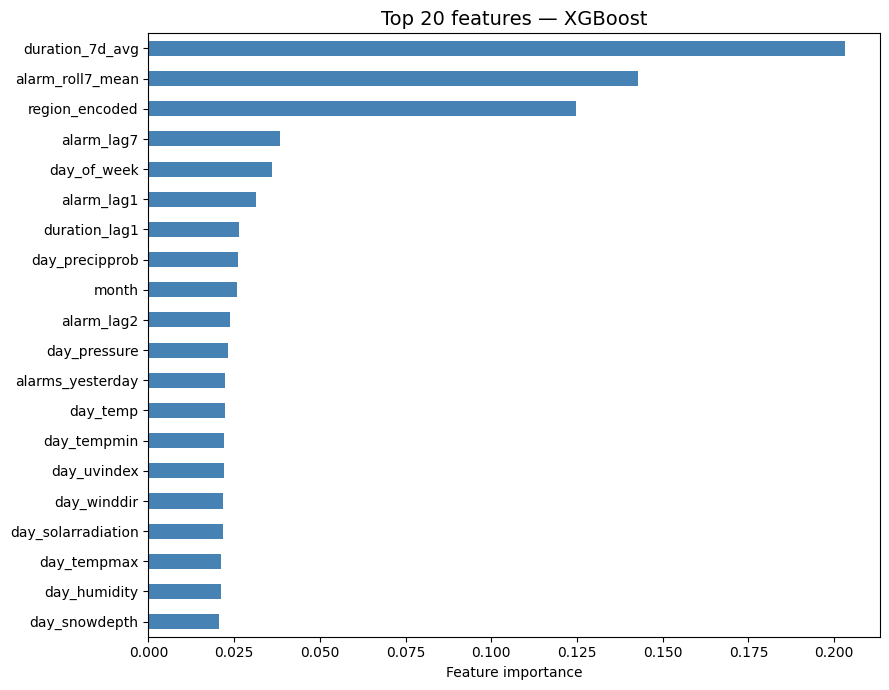

In [22]:
# ── 6. Top-20 feature importance ──────────────────────────────
importances = pd.Series(xgb_clf.feature_importances_, index=feature_cols)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
top20.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 features — XGBoost', fontsize=14)
ax.set_xlabel('Feature importance')
plt.tight_layout()
plt.show()